# Rewind — Exploratory Data Analysis

This notebook is the analytical foundation for **Rewind**, a Spotify listening-data analytics tool. It ingests a user's [Extended Streaming History](https://support.spotify.com/account/privacy-settings/) export, cleans and reshapes the data, then derives every metric the Rewind dashboard surfaces: total listening time, top artist / track / album, the GitHub-style activity heatmap, most-hated artist and track, active-day count, and unique-song count.

All discoveries here feed directly into the FastAPI backend endpoints defined in `backend/main.py` and the frontend cards rendered in `overview.html`.

---

## 1 · Environment Setup

Import the core analysis stack: **NumPy** for numeric operations, **Pandas** for tabular data, **Matplotlib** and **Seaborn** for visualization, and `pathlib` for portable file paths.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

## 2 · Project Root Resolution

Since this notebook lives inside `notebooks/`, we resolve the project root one level up. All subsequent data paths are relative to `base`, keeping the notebook runnable regardless of the working directory.

In [3]:
base = Path.cwd().parent

## 3 · Data Ingestion

Spotify delivers the Extended Streaming History as one or more JSON files, each containing an array of stream-event objects. Here we load **both export files** and concatenate them into a single DataFrame — the canonical dataset for every analysis that follows.

> **Note:** The schema of these JSON files is documented in `SCHEMA.md`. Each record represents one playback event and carries ~20 fields covering timestamp, platform, duration, geographic metadata, track/artist/album identifiers, and behavioral flags (shuffle, skip, offline, incognito).

In [4]:
part1 = pd.read_json(base / "data" / "Streaming_History_Audio_2025_1.json")
part2 = pd.read_json(base / "data" / "Streaming_History_Audio_2022-2025_0.json")
df = pd.concat([part1, part2], ignore_index=True)

## 4 · Initial Cleanup

Two cleanup steps run before any analysis:

1. **Drop empty columns** — Spotify's export sometimes includes columns that are entirely `NaN` (e.g., podcast-specific fields for a music-only listener). These add noise with zero analytical value.
2. **Drop `ip_addr`** — Personal network data carries real privacy risk and has no analytical use case in Rewind. This matches the backend's ingestion policy (see `SCHEMA.md` and `BACKEND.md`).

In [5]:
df.dropna(axis=1, how='all', inplace=True)
df.drop(columns=['ip_addr'], inplace=True)

## 5 · Type Casting

Raw JSON import leaves every column as a generic `object` dtype. Here we apply the correct types:

| Column | Target Type | Rationale |
|--------|-------------|----------|
| `ts` | `datetime64` | Enables date arithmetic, resampling, and heatmap bucketing |
| `platform`, `conn_country`, `reason_start`, `reason_end` | `category` | Low-cardinality strings — category dtype drastically reduces memory and speeds groupby |
| `shuffle`, `skipped`, `offline`, `incognito_mode` | `boolean` | Proper boolean semantics, nullable |

Correct dtypes are not cosmetic — they prevent silent bugs in aggregations (e.g., summing a string-typed boolean) and cut memory usage by ~40%.

In [6]:
df['ts'] = pd.to_datetime(df['ts'])
df['platform'] = df['platform'].astype('category')
df['conn_country'] = df['conn_country'].astype('category')
df['reason_start'] = df['reason_start'].astype('category')
df['reason_end'] = df['reason_end'].astype('category')
df['shuffle'] = df['shuffle'].astype('boolean')
df['skipped'] = df['skipped'].astype('boolean')
df['offline'] = df['offline'].astype('boolean')
df['incognito_mode'] = df['incognito_mode'].astype('boolean')

## 6 · Unit Conversion — Milliseconds → Minutes

Spotify records playback duration in **milliseconds** (`ms_played`). For human-readable metrics — total listening time, per-artist minutes — we convert to **minutes** in-place. The Rewind dashboard's "Total Listening Time" card consumes this value directly.

In [7]:
df['ms_played'] = df['ms_played'] / 1000 / 60  # Convert to minutes

## 7 · Schema Inspection

A quick `df.info()` sanity check to verify:
- All 17,648 stream events loaded successfully
- Dtypes are as expected after casting
- Non-null counts flag any remaining data-quality issues
- Memory footprint is reasonable (~1.7 MB for ~18k rows)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17648 entries, 0 to 17647
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype              
---  ------                             --------------  -----              
 0   ts                                 17648 non-null  datetime64[ns, UTC]
 1   platform                           17648 non-null  category           
 2   ms_played                          17648 non-null  float64            
 3   conn_country                       17648 non-null  category           
 4   master_metadata_track_name         17646 non-null  object             
 5   master_metadata_album_artist_name  17646 non-null  object             
 6   master_metadata_album_album_name   17646 non-null  object             
 7   spotify_track_uri                  17646 non-null  object             
 8   audiobook_title                    2 non-null      object             
 9   audiobook_uri                      2 non-null     

## 8 · Temporal Distribution of Listening Activity

A 100-bin histogram of the `ts` (timestamp) column reveals **when** listening happens over the life of the dataset. This visualization directly informs the Rewind dashboard's **GitHub-style listening activity heatmap** — it answers the question: *"Are there sustained periods of silence, or is listening fairly continuous?"*

Gaps in the distribution may indicate data export boundaries, device changes, or genuine listening breaks.

<Axes: >

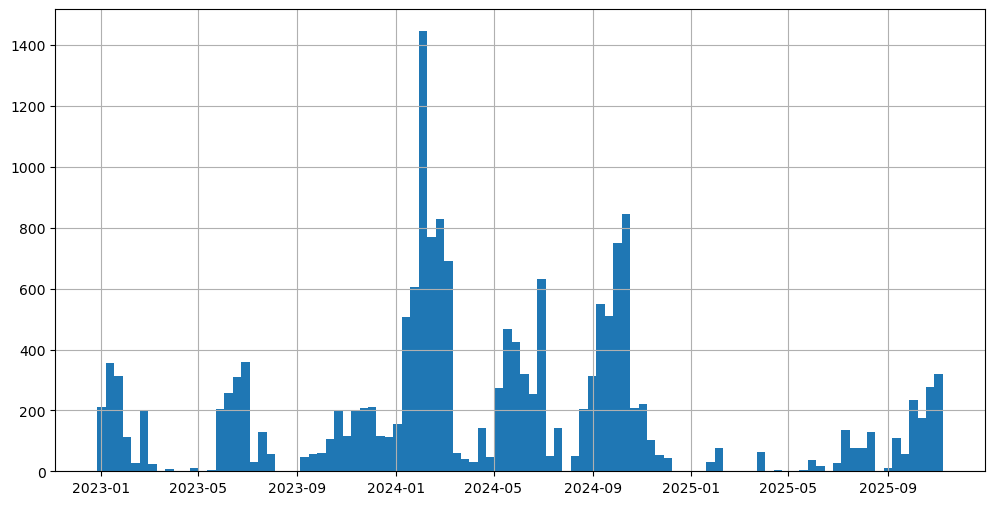

In [9]:
df['ts'].hist(bins=100, figsize=(12, 6))

## 9 · Top 10 Artists by Stream Count

A straightforward bar chart ranking artists by raw play count. This mirrors the logic behind Rewind's **Top Artist** metric card (`/api/metrics/top-artist`) — the artist with the most stream events wins. Stream count (rather than total minutes) is used here because it better reflects intentional engagement: a user who starts a track is making a choice, regardless of whether they listen to the full duration.

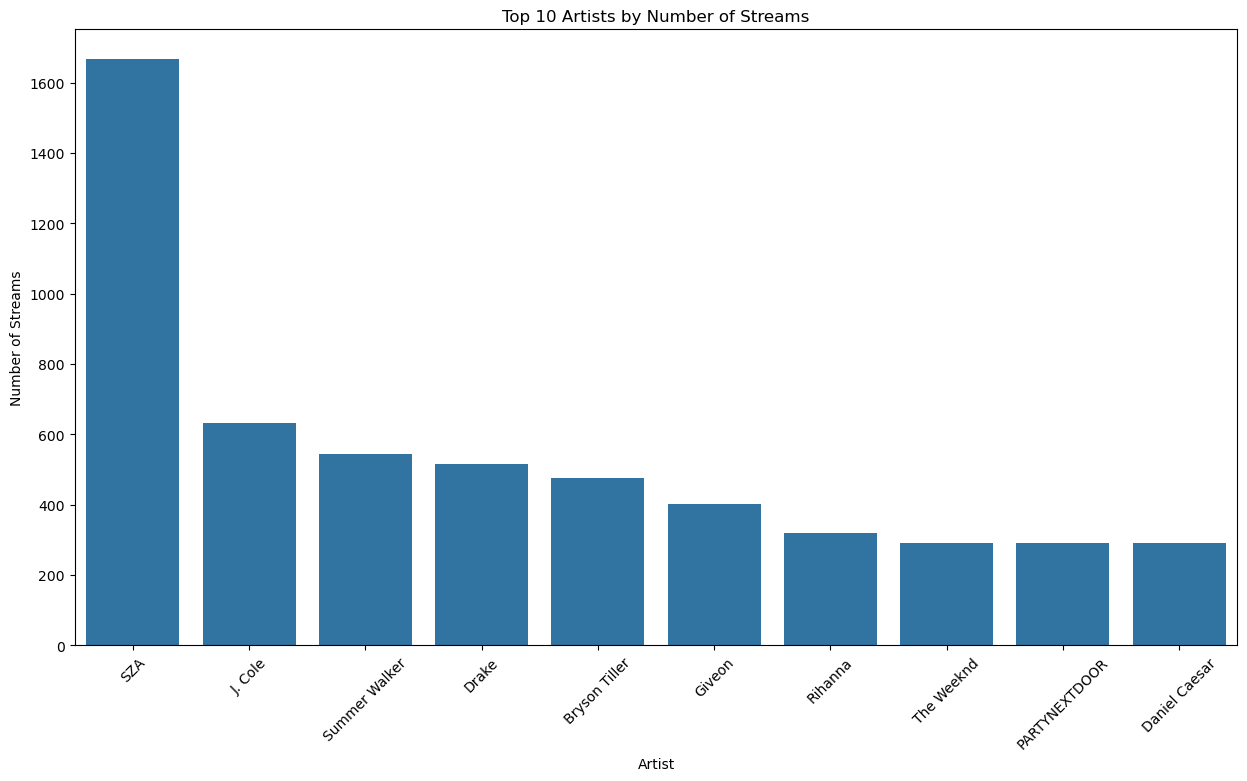

In [10]:
tmp = df['master_metadata_album_artist_name'].value_counts()
plt.figure(figsize=(15, 8))
sns.barplot(x=tmp.index[:10], y=tmp.values[:10])
plt.xticks(rotation=45)
plt.title('Top 10 Artists by Number of Streams')
plt.xlabel('Artist')
plt.ylabel('Number of Streams')
# plt.tight_layout()
plt.show()

## 10 · Full Dataset Preview

Display the complete DataFrame to visually spot-check field values, confirm dtypes are rendering correctly, and inspect edge cases (e.g., audiobook rows, very short `ms_played` values from skips, `reason_end` values like `unexpected-exit-while-paused`). This cell is a diagnostic checkpoint — not used in production.

In [11]:
df

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,audiobook_title,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode
0,2025-07-14 15:03:40+00:00,windows,2.387100,ET,Playing Games (with Bryson Tiller) - Extended ...,Summer Walker,Over It,spotify:track:2xyx0o4xNOLLjBSbOOdcbA,NaN,NaN,NaN,NaN,playbtn,trackdone,True,False,False,1752505275,False
1,2025-07-14 15:05:30+00:00,windows,1.823550,ET,BP,Summer Walker,Last Day Of Summer,spotify:track:7B1c8GzIeRVfuU7pqgmBaR,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505420,False
2,2025-07-14 15:09:20+00:00,windows,3.387333,ET,CPR,Summer Walker,Last Day Of Summer,spotify:track:5Tp4UJvnsF4Zd05k0zXUte,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505556,False
3,2025-07-14 15:12:06+00:00,windows,2.750000,ET,Spend It,Summer Walker,Spend It,spotify:track:290eKCMBc9f9CcSLFuQrim,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505760,False
4,2025-07-14 15:15:06+00:00,windows,2.999550,ET,I'll Kill You (feat. Jhené Aiko),Summer Walker,Over It,spotify:track:7EkiMl81fUHVwpItgtzI4r,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1752505926,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17643,2025-07-13 03:17:50+00:00,android,3.424300,ET,Calling My Phone,Lil Tjay,Destined 2 Win,spotify:track:3J8EOeKLTLXORtWPpOU5bE,None,None,None,None,trackdone,trackdone,True,False,False,1752376252,False
17644,2025-07-13 04:17:14+00:00,windows,4.047050,ET,2AM,SZA,Ctrl (Deluxe),spotify:track:3vZGtceCbJVh5aDT4XhE0p,None,None,None,None,clickrow,trackdone,False,False,False,1752379988,False
17645,2025-07-13 04:18:49+00:00,windows,1.162133,ET,Miles,SZA,Ctrl (Deluxe),spotify:track:4pHy0gmjfpD0Fgond5c4Ta,None,None,None,None,trackdone,trackdone,False,False,False,1752380259,False
17646,2025-07-13 04:20:13+00:00,windows,1.400000,ET,Percolator,SZA,Ctrl (Deluxe),spotify:track:4UJuFZ4btsiGqMyFHBRPbo,None,None,None,None,trackdone,trackdone,False,False,False,1752380328,False


---

## 11 · Skip-Rate Analysis — Artist Level

From here, the notebook shifts from descriptive summaries to **behavioral analytics**: identifying the user's *most-hated* artists and tracks. The Rewind dashboard surfaces a "Most Hated Artist" card — this section is its analytical backbone.

We group by artist and compute:
- `total_plays` — total stream events (denominator)
- `skips` — count of plays where `skipped == True` (numerator)
- `skip_rate` — proportion of streams the user skipped

Raw skip rate alone is misleading (an artist played once and skipped once has a 100% rate), so all downstream visualizations apply a minimum-play threshold to filter out low-sample noise.

In [12]:
artist_stats = df.groupby('master_metadata_album_artist_name').agg(
    total_plays=('ts', 'count'),
    skips=('skipped', 'sum')
)
artist_stats['skip_rate'] = artist_stats['skips'] / artist_stats['total_plays']


## 12 · Skip Rate vs. Total Plays — Artist Scatter Plot

This scatter plot maps every artist (with ≥ 30 plays) on two axes:
- **x-axis:** total play count — a proxy for familiarity
- **y-axis:** skip rate — a proxy for dislike

The **dashed gray line** marks the user's global average skip rate. Artists *above* the line are skipped more than average; artists *below* are listened to more patiently.

**Annotations:** The top-5 highest skip-rate artists are labeled in black; the top-4 most-played artists are labeled in red. The interesting quadrant is upper-right: artists the user plays frequently but also skips heavily — a love-hate signal.

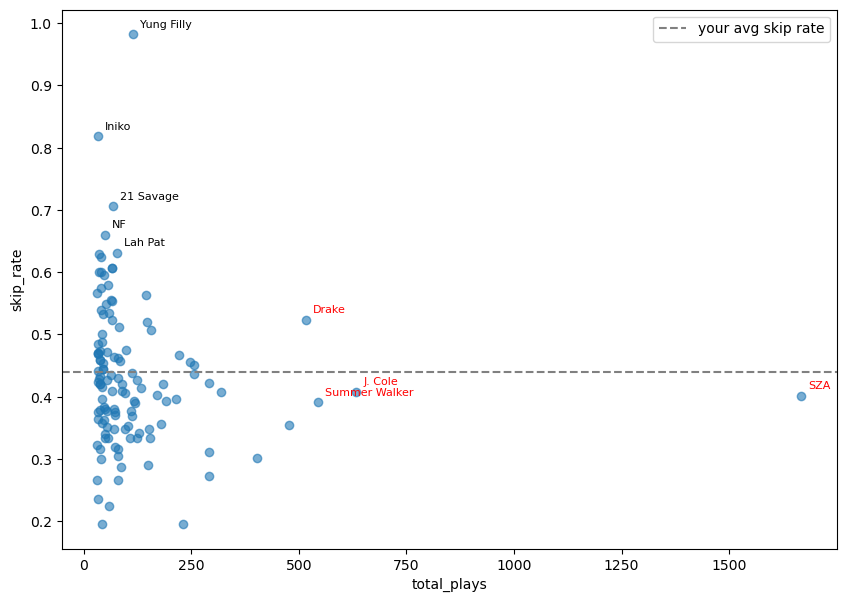

In [13]:
# only keep artists with a reasonable sample size, otherwise low-n noise dominates
filtered = artist_stats[artist_stats['total_plays'] >= 30].copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(filtered['total_plays'], filtered['skip_rate'], alpha=0.6)

# label only the extremes so it's not cluttered
top_candidates = filtered.sort_values('skip_rate', ascending=False).head(5)
top_favorite = filtered.sort_values('total_plays', ascending=False).head(4)

for name, row in top_candidates.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, xytext=(5,5), textcoords='offset points')
for name, row in top_favorite.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, color='red', xytext=(5,5), textcoords='offset points')

ax.axhline(df['skipped'].mean(), color='gray', linestyle='--', label='your avg skip rate')
ax.set_xlabel('total_plays')
ax.set_ylabel('skip_rate')
ax.legend()
plt.show()

## 13 · Skip-Rate Analysis — Track Level

The same skip-rate computation applied at the **track** granularity. This powers the Rewind dashboard's "Most Hated Track" card.

Tracks with ≥ 10 plays are retained and sorted by descending skip rate. The higher threshold for artists (30) vs. tracks (10) reflects that individual tracks naturally accumulate fewer plays than artist-level totals.

In [14]:
track_stats = df.groupby('master_metadata_track_name').agg(
    total_plays=('ts', 'count'),
    skips=('skipped', 'sum')
)
track_stats['skip_rate'] = track_stats['skips'] / track_stats['total_plays']

# filter out artists you've barely played, otherwise n=1 100%-skip artists dominate
track_stats[track_stats['total_plays'] >= 10].sort_values('skip_rate', ascending=False)

,total_plays,skips,skip_rate
master_metadata_track_name,,,
Grey,115,113,0.982609
She Make It Clap,15,14,0.933333
Yosemite (Song For The Ahwahnechee),14,13,0.928571
Drip Too Hard (Lil Baby & Gunna),13,11,0.846154
Rich Baby Daddy (feat. Sexyy Red & SZA),31,26,0.83871
...,...,...,...
STRANGERS,12,1,0.083333
See You Again (feat. Kali Uchis),14,1,0.071429
I CAN TELL,12,0,0.0


## 14 · Skip Rate vs. Total Plays — Track Scatter Plot

An analogous scatter plot at the track level (threshold: ≥ 20 plays). The same visual language applies: the gray dashed line is the global skip rate, top-5 highest skip-rate tracks labeled in black, top-4 most-played in red.

This view often reveals individual tracks that the user's playlist or autoplay feeds them repeatedly — but that they almost always skip.

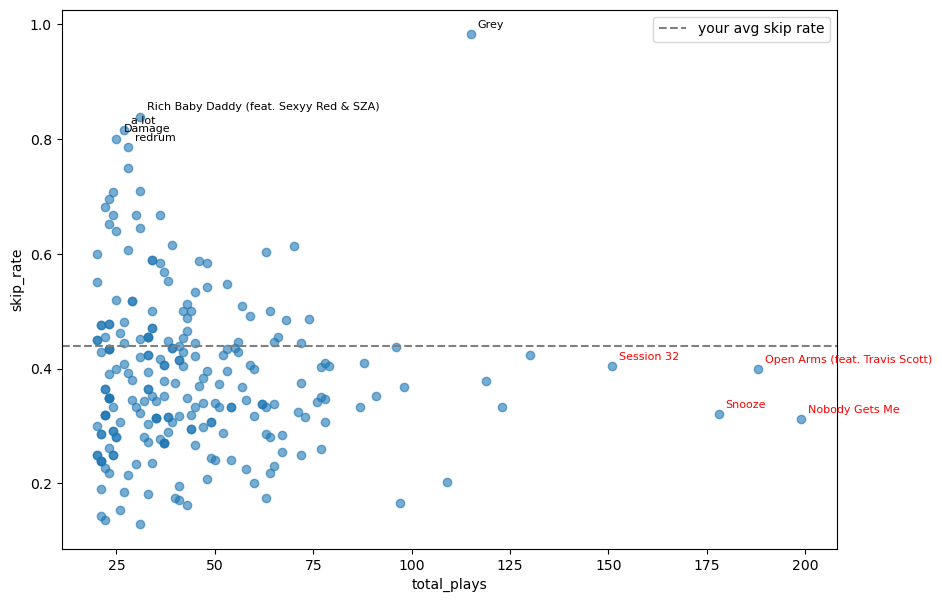

In [15]:
# only keep artists with a reasonable sample size, otherwise low-n noise dominates
filtered = track_stats[track_stats['total_plays'] >= 20].copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(filtered['total_plays'], filtered['skip_rate'], alpha=0.6)

# label only the extremes so it's not cluttered
top_candidates = filtered.sort_values('skip_rate', ascending=False).head(5)
top_favorite = filtered.sort_values('total_plays', ascending=False).head(4)

for name, row in top_candidates.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, xytext=(5,5), textcoords='offset points')
for name, row in top_favorite.iterrows():
    ax.annotate(name, (row['total_plays'], row['skip_rate']), fontsize=8, color='red', xytext=(5,5), textcoords='offset points')

ax.axhline(df['skipped'].mean(), color='gray', linestyle='--', label='your avg skip rate')
ax.set_xlabel('total_plays')
ax.set_ylabel('skip_rate')
ax.legend()
plt.show()

---

## 15 · Statistical Rigour — Binomial Test for Skip Surprise

Raw skip rates are noisy. Is an artist's 60% skip rate *meaningfully* higher than the user's global 35% rate, or just sampling noise from a handful of plays?

We use a **one-sided binomial test** (`scipy.stats.binomtest`) per artist:
- **H₀:** This artist's true skip probability equals the user's global skip rate
- **H₁:** This artist's true skip probability is *greater* (i.e., the user hates them more)

A small p-value means the observed skip count is unlikely under "normal" listening behavior. This transforms the naïve "sort by skip rate" approach into a statistically grounded ranking.

In [16]:
from scipy.stats import binomtest

global_skip_rate = df['skipped'].mean()  # your overall skip rate across everything

def skip_surprise(artist_name, p=global_skip_rate):
    skips = artist_stats.loc[artist_name, 'skips']
    plays = artist_stats.loc[artist_name, 'total_plays']
    result = binomtest(skips, plays, p, alternative='greater')
    return result.pvalue  # small = surprising, this artist isn't "just average"

## 16 · Compute Skip-Surprise p-Values

Apply the binomial test to **every artist** in the dataset, storing the resulting p-value in a new `skip_surprise` column. Smaller values → stronger evidence that the artist is genuinely skipped at an above-average rate.

In [17]:
artist_stats['skip_surprise'] = artist_stats.index.map(skip_surprise)

## 17 · Volcano-Style Plot — Statistical Significance of Skip Behavior

Inspired by genomics volcano plots, this chart maps:
- **x-axis (log scale):** total plays — how familiar the artist is
- **y-axis:** `-log10(p-value)` — how *surprising* their skip rate is (higher = more extreme)

The **dashed gray line** marks the p = 0.05 significance threshold. Points above it (colored crimson) are artists whose elevated skip rate is **statistically significant** — not just random noise.

The top-5 most-surprising artists are labeled. These are the strongest candidates for the Rewind "Most Hated Artist" title.

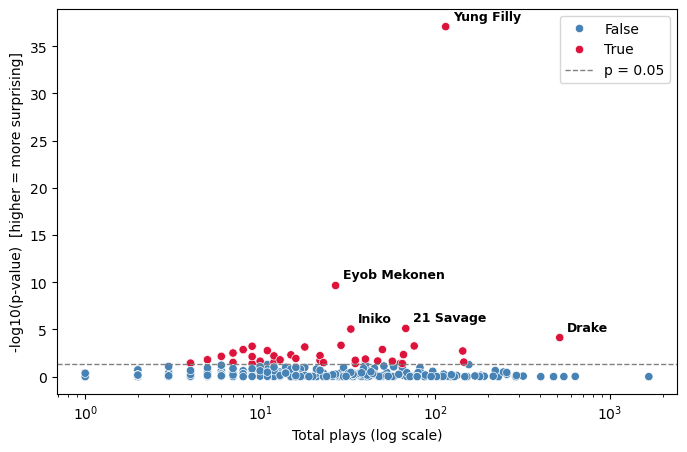

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# avoid log(0) for any p-values that underflowed to exactly 0
artist_stats['neg_log_p'] = -np.log10(artist_stats['skip_surprise'].clip(lower=1e-300))
artist_stats['significant'] = artist_stats['skip_surprise'] < 0.05

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=artist_stats, x='total_plays', y='neg_log_p',
    hue='significant', palette={True: 'crimson', False: 'steelblue'},
    ax=ax
)
top3 = artist_stats.nsmallest(5, 'skip_surprise')

for _, row in top3.iterrows():
    ax.annotate(
        row.name,  # swap this for whatever your artist name column is actually called
        xy=(row['total_plays'], row['neg_log_p']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=9, fontweight='bold'
    )
ax.set_xscale('log')
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=1, label='p = 0.05')
ax.set_xlabel('Total plays (log scale)')
ax.set_ylabel('-log10(p-value)  [higher = more surprising]')
ax.legend()
plt.show()

## 18 · Wilson Confidence Intervals for Skip Rate

The binomial test tells us *if* an artist's skip rate is unusual, but not *how much*. **Wilson score intervals** (via `statsmodels.stats.proportion.proportion_confint`) provide a 95% confidence band around each artist's true skip probability.

Wilson intervals are preferred over naïve Wald intervals because they perform well even at small sample sizes and extreme proportions (near 0 or 1) — exactly the regime low-play artists occupy.

In [19]:
from statsmodels.stats.proportion import proportion_confint

artist_stats['low'], artist_stats['high'] = zip(*artist_stats.apply(
    lambda row: proportion_confint(count=row['skips'], nobs=row['total_plays'], alpha=0.05, method='wilson'),
    axis=1
))

## 19 · Ranking by Lower Confidence Bound — The "Most Hated" Leaderboard

The final visualization sorts artists by the **lower bound** of their Wilson 95% CI, not by raw skip rate. This is the key insight: ranking by the lower bound penalizes artists with few plays (wide intervals push the lower bound down) and rewards artists where we have strong evidence of a high skip rate.

- **Crimson dots:** observed skip rate
- **Gray whiskers:** 95% Wilson confidence interval
- **Blue dashed line:** user's global skip rate

Artists whose entire CI sits above the global line are the most robustly "hated". The top result feeds directly into Rewind's **Most Hated Artist** dashboard card.

> **Production note:** The backend endpoint for this metric will mirror this methodology — sorting by the Wilson lower bound with a minimum-play threshold — ensuring the dashboard card is grounded in statistical confidence, not sampling noise.

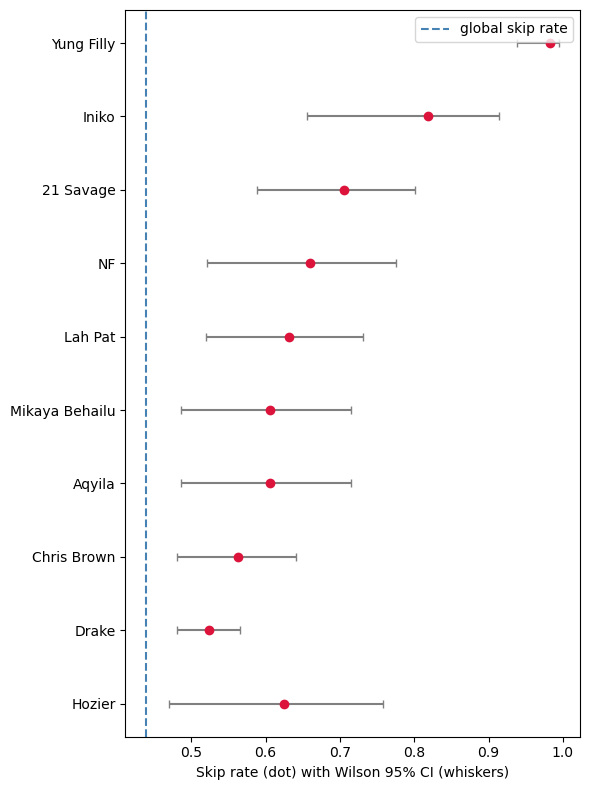

In [27]:
top_n = 10
artist_stats['raw_rate'] = artist_stats['skips'] / artist_stats['total_plays']
artist_stats = artist_stats[artist_stats['total_plays'] >= 20]  # filter out low-n artists

# sort by 'low', not raw_rate -- this IS the point of the whole exercise
top = artist_stats.nlargest(top_n, 'low').sort_values('low')

fig, ax = plt.subplots(figsize=(6, 8))
y_pos = range(len(top))

xerr_low = np.clip(top['raw_rate'] - top['low'], 0, None)
xerr_high = np.clip(top['high'] - top['raw_rate'], 0, None)

ax.errorbar(
    top['raw_rate'], y_pos,
    xerr=[xerr_low, xerr_high],
    fmt='o', color='crimson', ecolor='gray', capsize=3
)
ax.axvline(global_skip_rate, color='steelblue', linestyle='--', label='global skip rate')
ax.set_yticks(y_pos)
ax.set_yticklabels(top.index)
ax.set_xlabel('Skip rate (dot) with Wilson 95% CI (whiskers)')
ax.legend()
plt.tight_layout()
plt.show()